# Tutor Assistant - LangChain Walkthrough Notebook

This notebook walks you through the core capabilities from `requirements.md` and gives you an end-to-end test setup for handwriting recognition from your PDF notes using Bedrock + Amazon Nova Pro.

Target stack:
- LangChain orchestration
- Amazon Bedrock (Amazon Nova Pro)
- `pdf2image` for PDF -> image conversion
- Local test mode first, then extension to Google Drive/Calendar


## 1) Environment setup (UV)

Run these commands in your terminal (outside notebook):

```bash
uv venv
source .venv/bin/activate
uv pip install -U jupyter ipykernel boto3 pdf2image pillow pydantic python-dotenv
uv pip install -U langchain langchain-core langchain-aws langchain-community
# optional for benchmark extension
uv pip install -U python-Levenshtein pandas matplotlib
```

macOS dependency for pdf2image:
```bash
brew install poppler
```


In [32]:
# !uv pip install -U jupyter ipykernel boto3 pdf2image pillow pydantic python-dotenv
# !uv pip install -U langchain langchain-core langchain-aws langchain-community
# !uv pip install -U python-Levenshtein pandas matplotlib

In [33]:
# !brew install poppler

## 2) Expected env vars

Create `.env` file (or export vars in shell):

```dotenv
AWS_REGION=us-east-1
NOVA_PRO_MODEL_ID=amazon.nova-pro-v1:0
# optional: set when your account requires inference profile for Nova Pro
NOVA_PRO_INFERENCE_PROFILE_ARN=
AWS_ACCESS_KEY_ID=...
AWS_SECRET_ACCESS_KEY=...
# optional
AWS_SESSION_TOKEN=...
```

If you use AWS SSO/profile, keep credentials in AWS config and skip direct keys.


In [34]:
import os
import io
import re
import json
import time
import base64
from pathlib import Path
from typing import Any
from statistics import mean

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from pdf2image import convert_from_path
from PIL import Image

import boto3
from langchain_aws import ChatBedrockConverse
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

load_dotenv()
AWS_REGION = os.getenv("AWS_REGION", "eu-central-1")

def list_bedrock_nova_vision_models(region: str) -> list[str]:
    control = boto3.client("bedrock", region_name=region)
    response = control.list_foundation_models(byProvider="Amazon")
    ids: list[str] = []
    for m in response.get("modelSummaries", []):
        input_modalities = set(m.get("inputModalities", []))
        if "IMAGE" in input_modalities and "TEXT" in input_modalities and m["modelId"].startswith("amazon.nova"):
            ids.append(m["modelId"])
    return sorted(ids)

def resolve_nova_pro_model_id(region: str) -> str:
    # 1) explicit override from env
    env_id = os.getenv("NOVA_PRO_MODEL_ID")
    if env_id:
        return env_id.strip()

    # 2) prefer Nova Pro, fallback to any available Nova vision model
    preferred = [
        "amazon.nova-pro-v1:0",
    ]

    available = list_bedrock_nova_vision_models(region)

    for candidate in preferred:
        if candidate in available:
            return candidate

    if not available:
        raise RuntimeError("No Amazon Nova vision models found in this region.")

    return available[0]

NOVA_PRO_MODEL_ID = resolve_nova_pro_model_id(AWS_REGION)
NOVA_PRO_INFERENCE_PROFILE_ARN = os.getenv("NOVA_PRO_INFERENCE_PROFILE_ARN", "").strip()
NOVA_PRO_EFFECTIVE_MODEL_ID = NOVA_PRO_INFERENCE_PROFILE_ARN or NOVA_PRO_MODEL_ID
NOVA_PRO_PROVIDER = "amazon" if NOVA_PRO_EFFECTIVE_MODEL_ID.startswith("arn:") else None

print("AWS_REGION:", AWS_REGION)
print("NOVA_PRO_INFERENCE_PROFILE_ARN set:", bool(NOVA_PRO_INFERENCE_PROFILE_ARN))
print("NOVA_PRO_MODEL_ID:", NOVA_PRO_MODEL_ID)
print("NOVA_PRO_EFFECTIVE_MODEL_ID:", NOVA_PRO_EFFECTIVE_MODEL_ID)
print("NOVA_PRO_PROVIDER:", NOVA_PRO_PROVIDER)


AWS_REGION: eu-central-1
NOVA_PRO_INFERENCE_PROFILE_ARN set: True
NOVA_PRO_MODEL_ID: amazon.nova-pro-v1:0
NOVA_PRO_EFFECTIVE_MODEL_ID: arn:aws:bedrock:eu-central-1:708919751779:inference-profile/eu.amazon.nova-pro-v1:0
NOVA_PRO_PROVIDER: amazon


## 3) Output schema for math note analysis

This schema maps to FR1 and helps normalize output for FR2 progress tracking.


In [35]:
class NoteAnalysis(BaseModel):
    topics: list[str] = Field(default_factory=list, description="Detected math topics")
    tasks: list[str] = Field(default_factory=list, description="Detected exercises/problems")
    errors: list[str] = Field(default_factory=list, description="Potential solution mistakes")
    summary: str = Field(default="", description="Short summary of the page")

class LessonPlanningAnalysis(BaseModel):
    topics: list[str] = Field(default_factory=list, description="Detected math topics")
    task_types: list[str] = Field(default_factory=list, description="Types of tasks solved by student")
    tasks_count_estimate: int = Field(default=0, ge=0, description="Estimated number of solved tasks")
    summary: str = Field(default="", description="Short summary focused on lesson planning")

parser = JsonOutputParser(pydantic_object=NoteAnalysis)
format_instructions = parser.get_format_instructions()
planning_parser = JsonOutputParser(pydantic_object=LessonPlanningAnalysis)
planning_format_instructions = planning_parser.get_format_instructions()
planning_format_instructions[:400]


'STRICT OUTPUT FORMAT:\n- Return only the JSON value that conforms to the schema. Do not include any additional text, explanations, headings, or separators.\n- Do not wrap the JSON in Markdown or code fences (no ``` or ```json).\n- Do not prepend or append any text (e.g., do not write "Here is the JSON:").\n- The response must be a single top-level JSON value exactly as required by the schema (object/a'

## 4) PDF -> images helpers

Use your own PDF path in the next cell.


In [36]:
def pdf_to_images(pdf_path: str | Path, dpi: int = 220) -> list[Image.Image]:
    pdf_path = Path(pdf_path)
    if not pdf_path.exists():
        raise FileNotFoundError(f"File not found: {pdf_path}")
    return convert_from_path(str(pdf_path), dpi=dpi)

def image_to_base64_png(image: Image.Image) -> str:
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

def image_to_png_bytes(image: Image.Image) -> bytes:
    buffer = io.BytesIO()
    image.save(buffer, format="PNG")
    return buffer.getvalue()


## 5) Bedrock call (direct boto3) - best for debugging

This is your quick MVP test for handwriting recognition from PDF notes.


In [37]:
bedrock_runtime = boto3.client("bedrock-runtime", region_name=AWS_REGION)

def safe_json_extract(text: str) -> dict[str, Any]:
    text = text.strip()
    if text.startswith("```"):
        text = re.sub(r"^```[a-zA-Z]*\n|```$", "", text.strip(), flags=re.MULTILINE).strip()
    return json.loads(text)

def analyze_page_with_nova_pro(image: Image.Image, max_tokens: int = 1800) -> dict[str, Any]:
    img_bytes = image_to_png_bytes(image)

    prompt = (
        "Jesteś ekspertem wspierającym nauczyciela matematyki. Przeanalizuj stronę notatek ucznia (odręcznych i ewentualnie fragmentów drukowanych).\n"
        "Zwróć wyłącznie poprawny JSON z kluczami: topics, tasks, errors, summary.\n"
        "Wszystkie wartości tekstowe (elementy list i summary) muszą być po polsku. Klucze JSON pozostają po angielsku.\n"
        "Jeśli strona zawiera tylko teorię i brak rozwiązywanych zadań, ustaw tasks jako pustą listę [].\n"
        "Za zadania uznawaj także fragmenty drukowane (np. wklejone z książki), jeśli zawierają treść zadania lub rozwiązanie.\n"
        "topics/tasks/errors muszą być listami stringów, a summary pojedynczym stringiem."
    )

    response = bedrock_runtime.converse(
        modelId=NOVA_PRO_EFFECTIVE_MODEL_ID,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "image": {
                            "format": "png",
                            "source": {"bytes": img_bytes},
                        }
                    },
                    {"text": prompt},
                ],
            }
        ],
        inferenceConfig={"maxTokens": max_tokens, "temperature": 0},
    )

    text_chunks = [c.get("text", "") for c in response["output"]["message"]["content"] if "text" in c]
    text = "\n".join(t for t in text_chunks if t).strip()
    return safe_json_extract(text)

def analyze_page_for_lesson_plan(
    image: Image.Image,
    model_id: str | None = None,
    max_tokens: int = 1400,
) -> dict[str, Any]:
    img_bytes = image_to_png_bytes(image)
    selected_model = model_id or NOVA_PRO_EFFECTIVE_MODEL_ID

    prompt = (
        "Wspierasz nauczyciela matematyki w planowaniu kolejnej lekcji. Przeanalizuj stronę notatek (odręcznych i ewentualnie fragmentów drukowanych) i zwróć wyłącznie poprawny JSON. "
        "Skup się tylko na: (1) typach zadań oraz (2) szacowanej liczbie rozwiązanych zadań. "
        "Nie wykonuj detekcji błędów. "
        "Wszystkie wartości tekstowe (topics, task_types, summary) mają być po polsku; klucze JSON zostają po angielsku. "
        "Jeśli strona zawiera tylko teorię i brak zadań, ustaw task_types=[] oraz tasks_count_estimate=0. "
        "Za zadania uznawaj również fragmenty drukowane (np. wklejone z książki), jeśli zawierają treść zadania lub rozwiązanie.\n"
        + planning_format_instructions
    )

    response = bedrock_runtime.converse(
        modelId=selected_model,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "image": {
                            "format": "png",
                            "source": {"bytes": img_bytes},
                        }
                    },
                    {"text": prompt},
                ],
            }
        ],
        inferenceConfig={"maxTokens": max_tokens, "temperature": 0},
    )

    text_chunks = [c.get("text", "") for c in response["output"]["message"]["content"] if "text" in c]
    text = "\n".join(t for t in text_chunks if t).strip()
    return safe_json_extract(text)


Loaded pages: 84


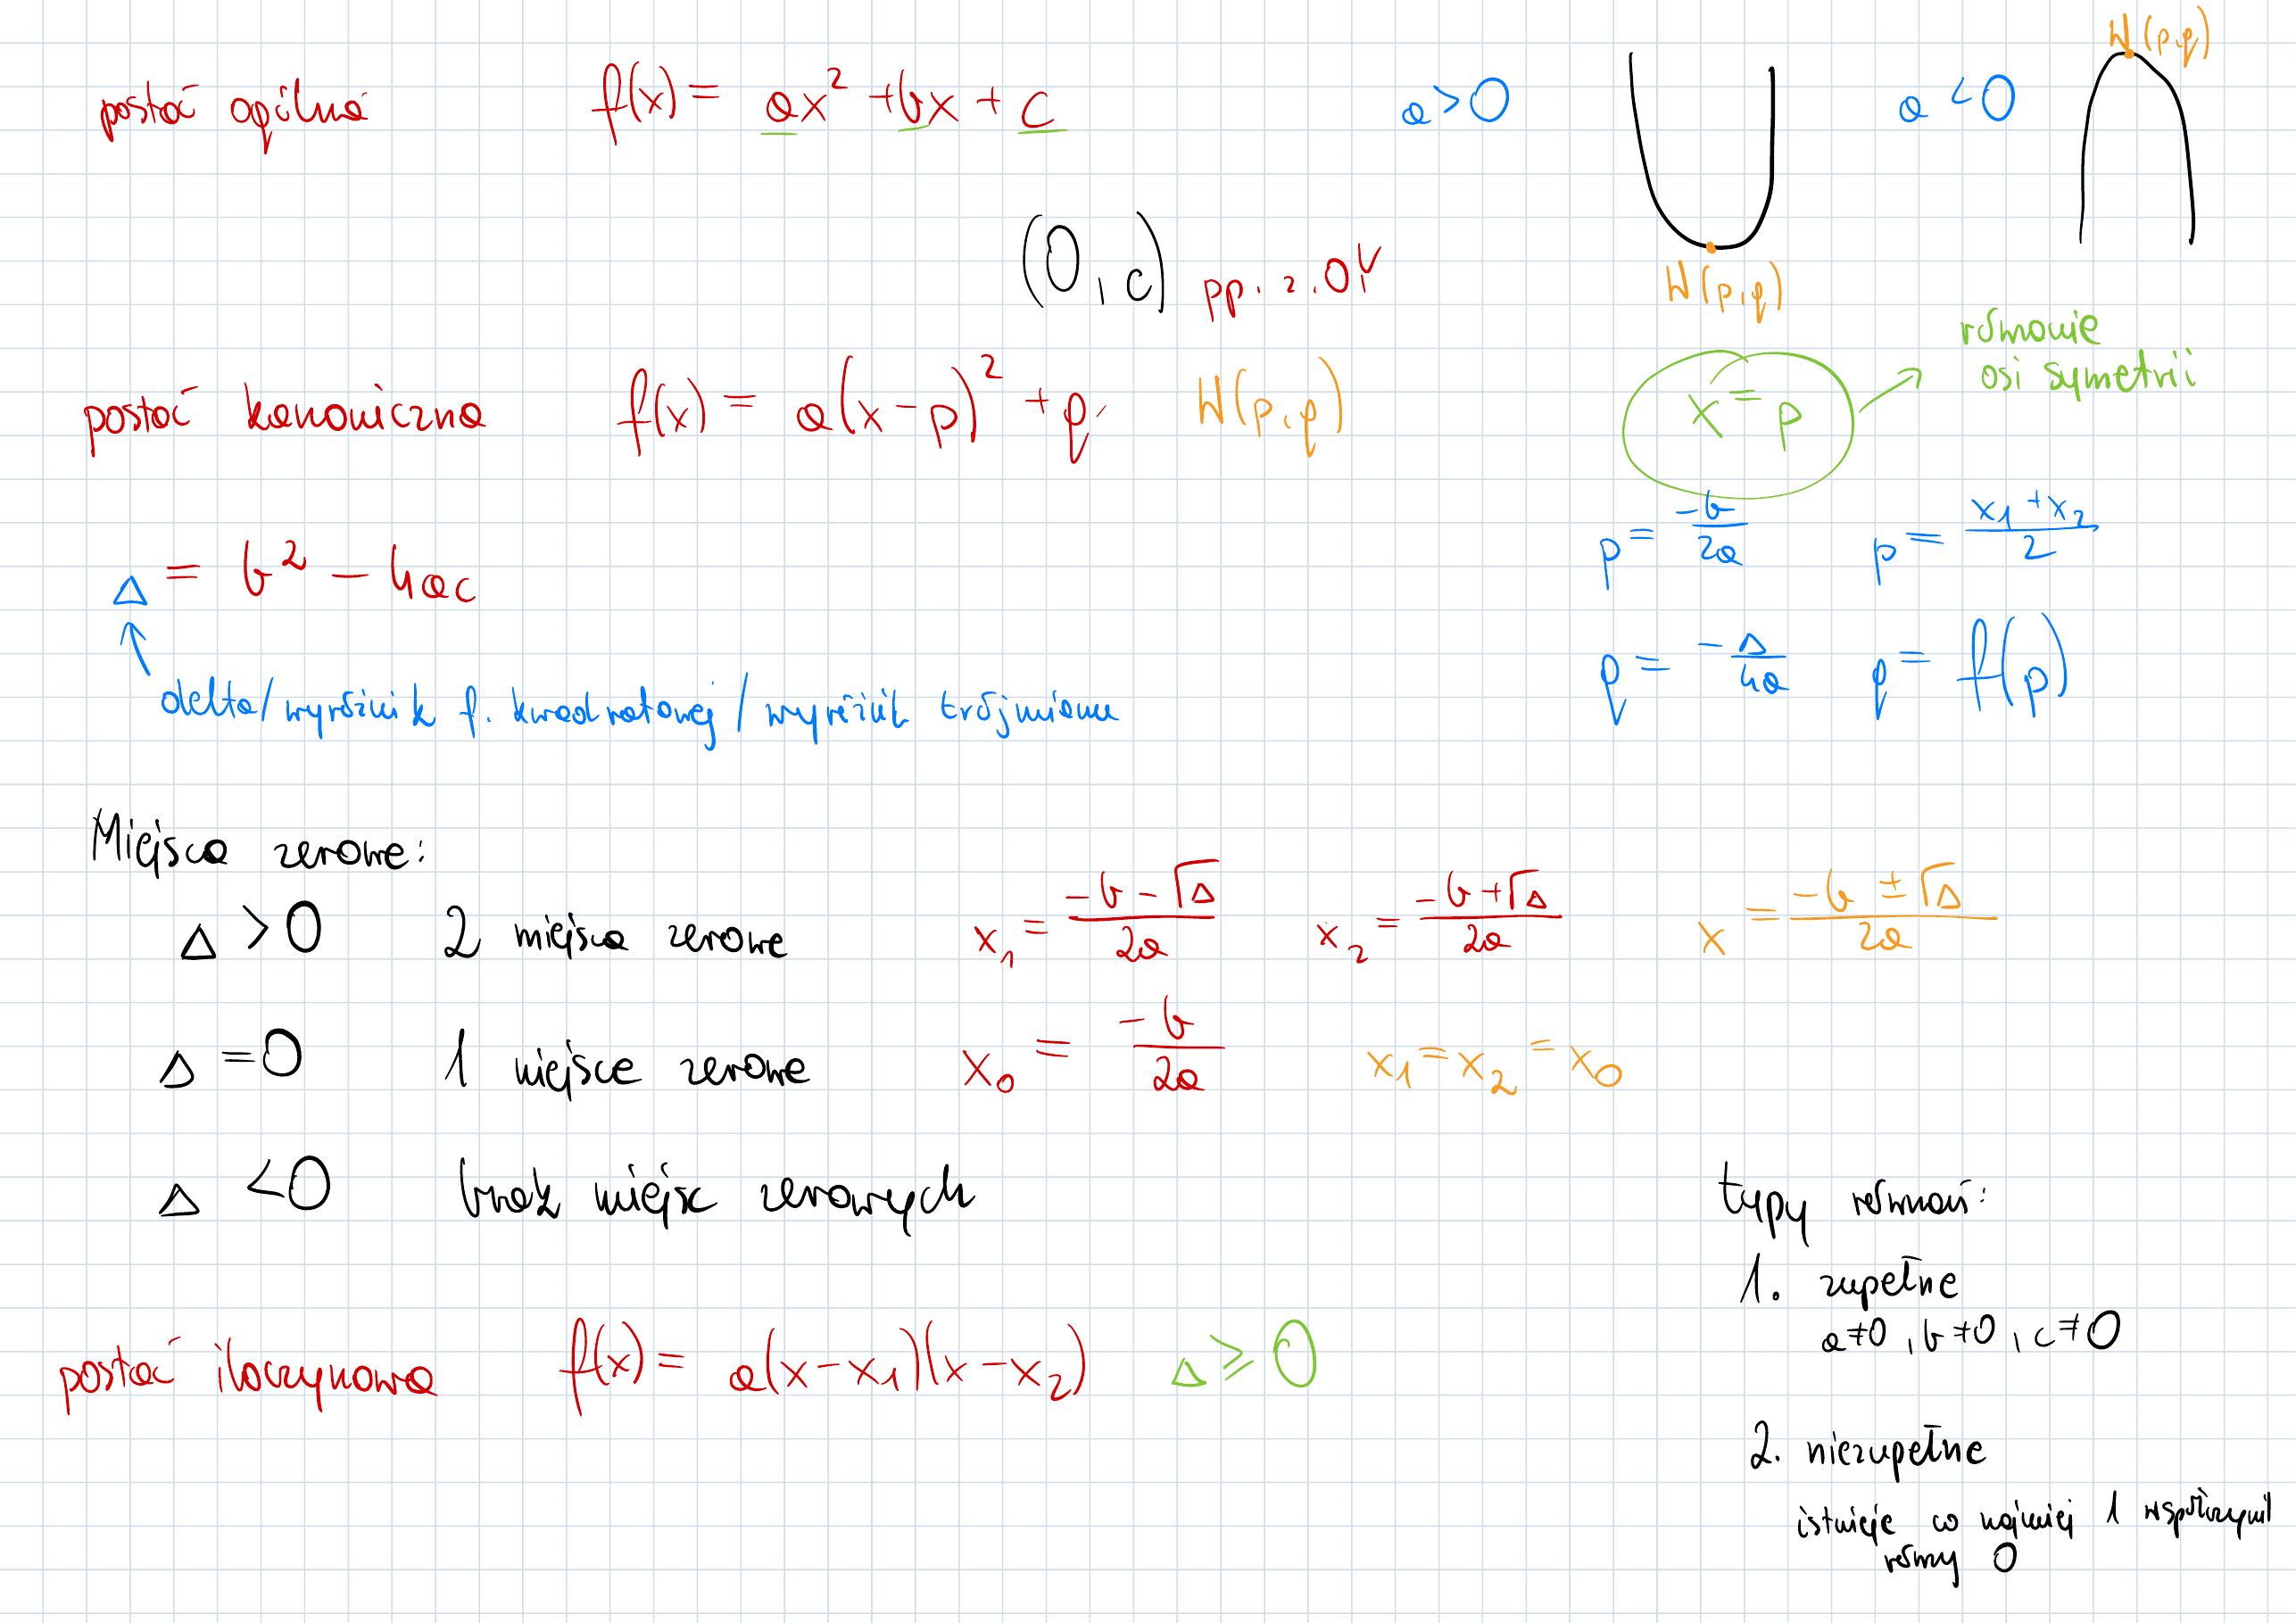

In [38]:
# Change this path to your own notes PDF
PDF_PATH = "data/Funkcja kwadratowa.pdf"

images = pdf_to_images(PDF_PATH, dpi=220)
print(f"Loaded pages: {len(images)}")

# preview first page
images[0]


In [39]:
t0 = time.time()
first_page_result = analyze_page_with_nova_pro(images[0])
latency_s = time.time() - t0

validated = NoteAnalysis.model_validate(first_page_result)
print(f"Latency (Nova Pro): {latency_s:.2f}s")
validated.model_dump()


Latency (Nova Pro): 2.90s


{'topics': ['Postać ogólna funkcji kwadratowej',
  'Postać kanoniczna funkcji kwadratowej',
  'Miejsca zerowe funkcji kwadratowej',
  'Postać iloczynowa funkcji kwadratowej'],
 'tasks': ['Znalezienie postaci kanonicznej funkcji kwadratowej',
  'Wyznaczenie miejsc zerowych funkcji kwadratowej',
  'Przekształcenie funkcji kwadratowej do postaci iloczynowej'],
 'errors': ["Błąd w obliczeniu współczynnika 'a' w postaci kanonicznej",
  'Nieprawidłowe obliczenie miejsc zerowych'],
 'summary': 'Strona zawiera notatki dotyczące różnych postaci funkcji kwadratowej: ogólnej, kanonicznej i iloczynowej. Uczeń ćwiczył przekształcanie funkcji do różnych postaci oraz wyznaczanie miejsc zerowych. Występują błędy w obliczeniach, które należy poprawić.'}

## 6) LangChain wrapper (same model, cleaner orchestration)

This part is useful when you start connecting FR2/FR3/FR4/FR5 in one workflow.


In [40]:
llm_kwargs = {
    "model_id": NOVA_PRO_EFFECTIVE_MODEL_ID,
    "region_name": AWS_REGION,
    "max_tokens": 1800,
}
if NOVA_PRO_PROVIDER is not None:
    llm_kwargs["provider"] = NOVA_PRO_PROVIDER

llm = ChatBedrockConverse(**llm_kwargs)

prompt = ChatPromptTemplate.from_messages([
    ("system", "Jesteś ekspertem wspierającym nauczyciela matematyki. Zwracaj wyłącznie poprawny JSON, a wszystkie wartości tekstowe zapisuj po polsku (klucze JSON pozostają po angielsku)."),
    ("human", "Przeanalizuj tekst OCR z notatek ucznia (odręcznych lub drukowanych): {ocr_text}. Jeśli to tylko teoria bez zadań, ustaw tasks=[]; uwzględniaj też zadania z fragmentów drukowanych.\n{format_instructions}")
])

chain = prompt | llm | parser

# Example: when you already have OCR text from an external OCR engine
example_ocr = "x^2 - 5x + 6 = 0; student solved x=1 and x=6; one root seems wrong"
structured = chain.invoke({"ocr_text": example_ocr, "format_instructions": format_instructions})
structured


{'topics': ['Równania kwadratowe', 'Rozwiązywanie równań'],
 'tasks': ['x^2 - 5x + 6 = 0'],
 'errors': ['Uczeń rozwiązał równanie x^2 - 5x + 6 = 0 i uzyskał x=1 oraz x=6. Wydaje się, że jedno z rozwiązań jest niepoprawne.'],
 'summary': 'Notatki ucznia zawierają równanie kwadratowe x^2 - 5x + 6 = 0. Uczeń uzyskał rozwiązania x=1 i x=6, z których jedno jest niepoprawne.'}

## 7) Minimal FR1-FR5 function scaffold

These are local notebook stubs that map directly to your required architecture and can be replaced with real Google/Twilio API calls later.


In [41]:
def fetch_latest_notes(student_id: str, local_pdf_path: str) -> list[Image.Image]:
    # TODO: replace with Google Drive API lookup by student folder
    print(f"[fetch_latest_notes] student_id={student_id}, source={local_pdf_path}")
    return pdf_to_images(local_pdf_path, dpi=220)

def analyze_math_content(images: list[Image.Image], max_pages: int | None = 3) -> list[NoteAnalysis]:
    results: list[NoteAnalysis] = []
    subset = images if max_pages is None else images[:max_pages]
    for idx, img in enumerate(subset, start=1):
        raw = analyze_page_with_nova_pro(img)
        parsed = NoteAnalysis.model_validate(raw)
        print(f"[analyze_math_content] page={idx} topics={len(parsed.topics)} errors={len(parsed.errors)}")
        results.append(parsed)
    return results

def analyze_notes_for_lesson_plan(
    images: list[Image.Image],
    max_pages: int | None = 3,
    model_id: str | None = None,
) -> list[LessonPlanningAnalysis]:
    results: list[LessonPlanningAnalysis] = []
    subset = images if max_pages is None else images[:max_pages]
    for idx, img in enumerate(subset, start=1):
        raw = analyze_page_for_lesson_plan(img, model_id=model_id)
        parsed = LessonPlanningAnalysis.model_validate(raw)
        print(f"[lesson_plan] page={idx} task_types={len(parsed.task_types)} tasks_count={parsed.tasks_count_estimate}")
        results.append(parsed)
    return results

def get_daily_schedule() -> list[dict[str, str]]:
    # TODO: replace with Google Calendar API
    return [
        {"time": "09:00", "student": "Student_A", "topic_hint": "Quadratic equations"},
        {"time": "17:00", "student": "Student_B", "topic_hint": "Trigonometry"},
    ]

def update_student_progress_file(student_id: str, analyses: list[LessonPlanningAnalysis], out_dir: str = "outputs") -> Path:
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    merged_topics = sorted({t for a in analyses for t in a.topics})
    merged_task_types = sorted({t for a in analyses for t in a.task_types})
    total_tasks_estimate = sum(a.tasks_count_estimate for a in analyses)

    payload = {
        "student_id": student_id,
        "topics_seen": merged_topics,
        "task_types_seen": merged_task_types,
        "tasks_count_estimate": total_tasks_estimate,
        "pages_analyzed": len(analyses),
        "updated_at_epoch": int(time.time()),
    }

    dst = out / f"progress_{student_id}.json"
    dst.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"[update_student_progress_file] wrote: {dst}")
    return dst


In [42]:
# End-to-end local simulation for lesson planning (no error detection)
student_id = "student_demo"
images = fetch_latest_notes(student_id, PDF_PATH)
analyses = analyze_notes_for_lesson_plan(images, max_pages=10, model_id=NOVA_PRO_EFFECTIVE_MODEL_ID)
progress_file = update_student_progress_file(student_id, analyses)
progress_file


[fetch_latest_notes] student_id=student_demo, source=data/Funkcja kwadratowa.pdf
[lesson_plan] page=1 task_types=2 tasks_count=4
[lesson_plan] page=2 task_types=3 tasks_count=15
[lesson_plan] page=3 task_types=5 tasks_count=5
[lesson_plan] page=4 task_types=4 tasks_count=5
[lesson_plan] page=5 task_types=4 tasks_count=4
[lesson_plan] page=6 task_types=4 tasks_count=2
[lesson_plan] page=7 task_types=4 tasks_count=4
[lesson_plan] page=8 task_types=3 tasks_count=6
[lesson_plan] page=9 task_types=3 tasks_count=3
[lesson_plan] page=10 task_types=10 tasks_count=12
[update_student_progress_file] wrote: outputs/progress_student_demo.json


PosixPath('outputs/progress_student_demo.json')

## 8) Nova Pro deep dive (lesson-planning extraction + latency + usage)

Use this section to inspect Nova Pro behavior page-by-page: latency, token usage, stop reason, parsing quality, and extracted planning signal.


In [43]:
def analyze_page_for_lesson_plan_detailed(
    image: Image.Image,
    model_id: str | None = None,
    max_tokens: int = 1400,
) -> dict[str, Any]:
    img_bytes = image_to_png_bytes(image)
    selected_model = model_id or NOVA_PRO_EFFECTIVE_MODEL_ID

    prompt = (
        "Wspierasz nauczyciela matematyki w planowaniu kolejnej lekcji. Przeanalizuj stronę notatek (odręcznych i ewentualnie fragmentów drukowanych) i zwróć wyłącznie poprawny JSON. "
        "Skup się tylko na: (1) typach zadań oraz (2) szacowanej liczbie rozwiązanych zadań. "
        "Nie wykonuj detekcji błędów. "
        "Wszystkie wartości tekstowe (topics, task_types, summary) mają być po polsku; klucze JSON zostają po angielsku. "
        "Jeśli strona zawiera tylko teorię i brak zadań, ustaw task_types=[] oraz tasks_count_estimate=0. "
        "Za zadania uznawaj również fragmenty drukowane (np. wklejone z książki), jeśli zawierają treść zadania lub rozwiązanie.\n"
        + planning_format_instructions
    )

    t0 = time.time()
    response = bedrock_runtime.converse(
        modelId=selected_model,
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "image": {
                            "format": "png",
                            "source": {"bytes": img_bytes},
                        }
                    },
                    {"text": prompt},
                ],
            }
        ],
        inferenceConfig={"maxTokens": max_tokens, "temperature": 0},
    )
    latency_s = time.time() - t0

    output_message = response.get("output", {}).get("message", {})
    content = output_message.get("content", [])
    text_chunks = [c.get("text", "") for c in content if "text" in c]
    text = "\n".join(t for t in text_chunks if t).strip()

    usage = response.get("usage", {})
    stop_reason = response.get("stopReason")

    details: dict[str, Any] = {
        "model_id": selected_model,
        "latency_s": round(latency_s, 2),
        "stop_reason": stop_reason,
        "input_tokens": usage.get("inputTokens"),
        "output_tokens": usage.get("outputTokens"),
        "total_tokens": usage.get("totalTokens"),
        "raw_response_text": text,
    }

    try:
        parsed = LessonPlanningAnalysis.model_validate(safe_json_extract(text))
        details.update(
            {
                "parse_status": "ok",
                "tasks_count_estimate": parsed.tasks_count_estimate,
                "task_types_n": len(parsed.task_types),
                "task_types": parsed.task_types,
                "topics_n": len(parsed.topics),
                "topics": parsed.topics,
                "summary": parsed.summary,
            }
        )
    except Exception as e:
        details.update(
            {
                "parse_status": f"error: {type(e).__name__}",
                "tasks_count_estimate": None,
                "task_types_n": None,
                "task_types": [],
                "topics_n": None,
                "topics": [],
                "summary": "",
            }
        )

    return details


def benchmark_nova_pro_detailed(
    pdf_path: str,
    pages: int = 5,
    model_id: str | None = None,
) -> list[dict[str, Any]]:
    imgs = pdf_to_images(pdf_path, dpi=220)[:pages]
    rows: list[dict[str, Any]] = []

    for i, img in enumerate(imgs, start=1):
        row = analyze_page_for_lesson_plan_detailed(img, model_id=model_id)
        row["page"] = i
        rows.append(row)

    latencies = [r["latency_s"] for r in rows if isinstance(r.get("latency_s"), (int, float))]
    total_tokens = [r["total_tokens"] for r in rows if isinstance(r.get("total_tokens"), int)]

    rows.append(
        {
            "page": "AVG",
            "model_id": model_id or NOVA_PRO_EFFECTIVE_MODEL_ID,
            "latency_s": round(mean(latencies), 2) if latencies else None,
            "stop_reason": "summary",
            "input_tokens": None,
            "output_tokens": None,
            "total_tokens": round(mean(total_tokens), 1) if total_tokens else None,
            "parse_status": "summary",
            "tasks_count_estimate": sum(r.get("tasks_count_estimate", 0) or 0 for r in rows if isinstance(r.get("page"), int)),
            "task_types_n": sum(r.get("task_types_n", 0) or 0 for r in rows if isinstance(r.get("page"), int)),
            "task_types": [],
            "topics_n": None,
            "topics": [],
            "summary": "",
            "raw_response_text": "",
        }
    )

    return rows


nova_deep_dive = benchmark_nova_pro_detailed(PDF_PATH, pages=10, model_id=NOVA_PRO_EFFECTIVE_MODEL_ID)
nova_deep_dive


[{'model_id': 'arn:aws:bedrock:eu-central-1:708919751779:inference-profile/eu.amazon.nova-pro-v1:0',
  'latency_s': 1.91,
  'stop_reason': 'end_turn',
  'input_tokens': 2376,
  'output_tokens': 156,
  'total_tokens': 2532,
  'raw_response_text': '{\n  "topics": [\n    "funkcje kwadratowe",\n    "funkcje wielomianowe",\n    "równania kwadratowe",\n    "nierówności kwadratowe"\n  ],\n  "task_types": [\n    "zadania teoretyczne",\n    "zadania praktyczne"\n  ],\n  "tasks_count_estimate": 4,\n  "summary": "Lekcja obejmuje analizę funkcji kwadratowych i wielomianowych, w tym równań i nierówności kwadratowych. Uczniowie będą rozwiązywać zadania teoretyczne i praktyczne."\n}',
  'parse_status': 'ok',
  'tasks_count_estimate': 4,
  'task_types_n': 2,
  'task_types': ['zadania teoretyczne', 'zadania praktyczne'],
  'topics_n': 4,
  'topics': ['funkcje kwadratowe',
   'funkcje wielomianowe',
   'równania kwadratowe',
   'nierówności kwadratowe'],
  'summary': 'Lekcja obejmuje analizę funkcji kwa

## 9) How to read Nova Pro results

Interpretation tips:
- check `stop_reason` first to confirm clean completions,
- compare `input_tokens` vs `output_tokens` to understand cost drivers,
- inspect `raw_response_text` when `parse_status` is not `ok`,
- track `task_types_n` and `tasks_count_estimate` consistency across pages.

If Nova Pro requires an inference profile in your account/region, set:
- `NOVA_PRO_INFERENCE_PROFILE_ARN` in `.env`

For stable averages, test on at least 5-10 pages.
